In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
conn = sqlite3.connect("../data/soccer.db")

In [3]:
scaler = StandardScaler()
ROLLING_WINDOW = 5
INITIAL_ELO = 1500
ELO_K = 20
HOME_ADVANTAGE = 100

In [4]:
query = """
SELECT
    m.*,
    c.name AS competition_name

FROM matches m

JOIN competitions c
ON m.competition_id = c.id
"""

matches_df = pd.read_sql(query, conn)

In [5]:
matches_df["result"] = matches_df.apply(
    lambda row:
        "H" if row["home_goals"] > row["away_goals"]
        else "A" if row["home_goals"] < row["away_goals"]
        else "D",
    axis=1
)
matches_df["total_goals"] = (
    matches_df["home_goals"] +
    matches_df["away_goals"]
)
matches_df["over_2_5"] = (
    matches_df["total_goals"] > 2.5
)
matches_df["btts"] = (
    (matches_df["home_goals"] > 0) &
    (matches_df["away_goals"] > 0)
)
matches_df["is_draw"] = (
    matches_df["home_goals"] ==
    matches_df["away_goals"]
)

In [6]:
completed_matches = matches_df[
    matches_df["status"].isin([
        "FT",
        "AET",
        "PEN"
    ])
].copy()

In [7]:
matches_df.columns

Index(['id', 'api_fixture_id', 'competition_id', 'season', 'date', 'round',
       'home_team_id', 'away_team_id', 'home_goals', 'away_goals', 'status',
       'referee', 'competition_name', 'result', 'total_goals', 'over_2_5',
       'btts', 'is_draw'],
      dtype='str')

In [8]:
completed_matches.columns

Index(['id', 'api_fixture_id', 'competition_id', 'season', 'date', 'round',
       'home_team_id', 'away_team_id', 'home_goals', 'away_goals', 'status',
       'referee', 'competition_name', 'result', 'total_goals', 'over_2_5',
       'btts', 'is_draw'],
      dtype='str')

In [9]:
completed_matches = completed_matches.sort_values(
    by="date"
)

In [10]:
matches_df["home_goals"].describe()

count    21250.000000
mean         1.542165
std          1.292847
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: home_goals, dtype: float64

In [11]:
matches_df["away_goals"].describe()

count    21250.000000
mean         1.235247
std          1.158464
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: away_goals, dtype: float64

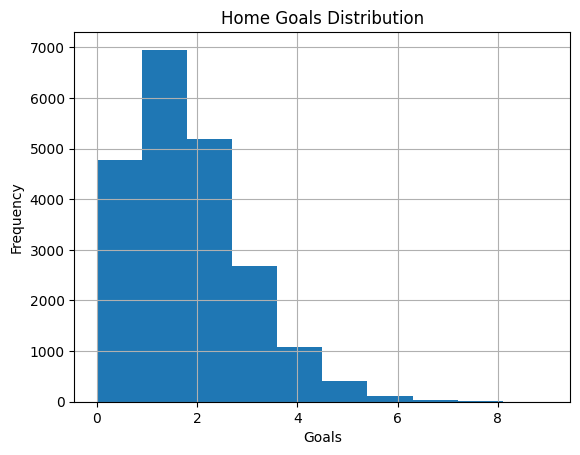

In [12]:
matches_df["home_goals"].hist(
    bins=10
)

plt.title("Home Goals Distribution")

plt.xlabel("Goals")

plt.ylabel("Frequency")

plt.show()

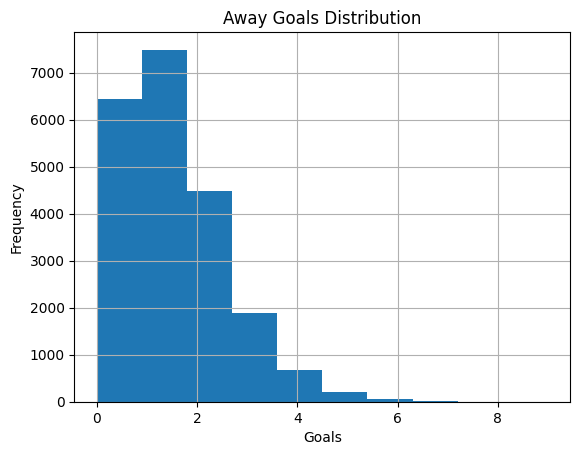

In [13]:
matches_df["away_goals"].hist(
    bins=10
)

plt.title("Away Goals Distribution")

plt.xlabel("Goals")

plt.ylabel("Frequency")

plt.show()

In [14]:
matches_df["result"].value_counts(normalize=True)

result
H    0.437716
A    0.302657
D    0.259627
Name: proportion, dtype: float64

In [15]:
matches_df["status"].value_counts()

status
FT      21226
CANC      164
NS         36
PEN        19
AET         4
ABD         1
Name: count, dtype: int64

In [16]:
completed_matches["home_goals"].mean()

np.float64(1.5422372817544354)

In [17]:
completed_matches["away_goals"].mean()

np.float64(1.2353051908325097)

In [18]:
(
    completed_matches["home_goals"] +
    completed_matches["away_goals"]
).mean()

np.float64(2.777542472586945)

In [19]:
query = """
SELECT
    m.*,
    c.name AS competition_name

FROM matches m

JOIN competitions c
ON m.competition_id = c.id
"""

matches_df = pd.read_sql(query, conn)

matches_df.head()

,id,api_fixture_id,competition_id,season,date,round,home_team_id,away_team_id,home_goals,away_goals,status,referee,competition_name
0,1,592143,1,2020,2020-09-12 11:30:00.000000,Regular Season - 1,3,7,0.0,3.0,FT,C. Kavanagh,Premier League
1,2,592142,1,2020,2020-09-12 14:00:00.000000,Regular Season - 1,16,6,1.0,0.0,FT,J. Moss,Premier League
2,3,592144,1,2020,2020-09-12 16:30:00.000000,Regular Season - 1,5,19,4.0,3.0,FT,M. Oliver,Premier League
3,4,592148,1,2020,2020-09-12 19:00:00.000000,Regular Season - 1,12,2,0.0,2.0,FT,S. Attwell,Premier League
4,5,592147,1,2020,2020-09-13 13:00:00.000000,Regular Season - 1,17,10,0.0,3.0,FT,A. Taylor,Premier League


In [20]:
completed_matches.groupby(
    "competition_name"
)[
    ["home_goals", "away_goals"]
].mean()

,home_goals,away_goals
competition_name,,
Bundesliga,1.718282,1.376057
La Liga,1.483641,1.133509
Liga MX,1.529837,1.161242
Ligue 1,1.512622,1.215146
Premier League,1.555937,1.280211
Serie A,1.482458,1.261409


In [21]:
completed_matches["total_goals"] = (
    completed_matches["home_goals"] +
    completed_matches["away_goals"]
)

In [22]:
completed_matches["is_draw"] = (
    completed_matches["home_goals"] ==
    completed_matches["away_goals"]
)

In [23]:
completed_matches.groupby(
    "competition_name"
)["is_draw"].mean()

competition_name
Bundesliga        0.249187
La Liga           0.262269
Liga MX           0.265220
Ligue 1           0.253012
Premier League    0.232190
Serie A           0.254814
Name: is_draw, dtype: float64

In [24]:
completed_matches.groupby(
    "competition_name"
)["result"].value_counts(normalize=True)

competition_name  result
Bundesliga        H         0.440468
                  A         0.310345
                  D         0.249187
La Liga           H         0.454354
                  A         0.283377
                  D         0.262269
Liga MX           H         0.452381
                  A         0.282399
                  D         0.265220
Ligue 1           H         0.438612
                  A         0.308376
                  D         0.253012
Premier League    H         0.446438
                  A         0.321372
                  D         0.232190
Serie A           H         0.419678
                  A         0.325508
                  D         0.254814
Name: proportion, dtype: float64

In [25]:
completed_matches["over_2_5"] = (
    completed_matches["total_goals"] > 2.5
)

In [26]:
completed_matches.groupby(
    "competition_name"
)["over_2_5"].mean()

competition_name
Bundesliga        0.598243
La Liga           0.479947
Liga MX           0.507233
Ligue 1           0.517785
Premier League    0.544063
Serie A           0.526510
Name: over_2_5, dtype: float64

In [27]:
completed_matches["btts"] = (
    (completed_matches["home_goals"] > 0) &
    (completed_matches["away_goals"] > 0)
)

In [28]:
completed_matches.groupby(
    "competition_name"
)["btts"].mean()

competition_name
Bundesliga        0.587508
La Liga           0.514776
Liga MX           0.547318
Ligue 1           0.525244
Premier League    0.527441
Serie A           0.538908
Name: btts, dtype: float64

In [29]:
completed_matches = completed_matches.sort_values(
    by="date"
)

In [30]:
home_df = completed_matches[
    [
        "date",
        "competition_name",
        "season",
        "home_team_id",
        "home_goals",
        "away_goals"
    ]
].copy()

home_df.columns = [
    "date",
    "competition_name",
    "season",
    "team_id",
    "goals_scored",
    "goals_conceded"
]

In [31]:
away_df = completed_matches[
    [
        "date",
        "competition_name",
        "season",
        "away_team_id",
        "away_goals",
        "home_goals"
    ]
].copy()

away_df.columns = [
    "date",
    "competition_name",
    "season",
    "team_id",
    "goals_scored",
    "goals_conceded"
]

In [32]:
team_history = pd.concat(
    [home_df, away_df]
)

In [33]:
team_history = team_history.sort_values(
    by=["team_id", "date"]
)

In [34]:
team_history["rolling_goals_scored"] = (
    team_history
    .groupby("team_id")["goals_scored"]
    .transform(
        lambda x:
            x.shift(1).rolling(5).mean()
    )
)

In [35]:
team_history["rolling_goals_conceded"] = (
    team_history
    .groupby("team_id")["goals_conceded"]
    .transform(
        lambda x:
            x.shift(1).rolling(5).mean()
    )
)

In [36]:
team_history.head(20)

,date,competition_name,season,team_id,goals_scored,goals_conceded,rolling_goals_scored,rolling_goals_conceded
10714,2016-08-14 12:30:00.000000,Premier League,2016,1,3.0,1.0,NaN,NaN
10717,2016-08-19 19:00:00.000000,Premier League,2016,1,2.0,0.0,NaN,NaN
10734,2016-08-27 16:30:00.000000,Premier League,2016,1,1.0,0.0,NaN,NaN
10737,2016-09-10 11:30:00.000000,Premier League,2016,1,1.0,2.0,NaN,NaN
10753,2016-09-18 11:00:00.000000,Premier League,2016,1,1.0,3.0,NaN,NaN
10757,2016-09-24 11:30:00.000000,Premier League,2016,1,4.0,1.0,1.6,1.2
10773,2016-10-02 11:00:00.000000,Premier League,2016,1,1.0,1.0,1.8,1.2
10786,2016-10-17 19:00:00.000000,Premier League,2016,1,0.0,0.0,1.6,1.4
10796,2016-10-23 15:00:00.000000,Premier League,2016,1,0.0,4.0,1.4,1.4
10798,2016-10-29 14:00:00.000000,Premier League,2016,1,0.0,0.0,1.2,1.8


In [37]:
home_features = team_history.copy()

home_features = home_features.rename(
    columns={
        "team_id": "home_team_id",

        "rolling_goals_scored":
            "home_rolling_scored",

        "rolling_goals_conceded":
            "home_rolling_conceded"
    }
)

In [38]:
away_features = team_history.copy()

away_features = away_features.rename(
    columns={
        "team_id": "away_team_id",

        "rolling_goals_scored":
            "away_rolling_scored",

        "rolling_goals_conceded":
            "away_rolling_conceded"
    }
)

In [39]:
matches_features = completed_matches.merge(
    home_features[
        [
            "date",
            "home_team_id",
            "home_rolling_scored",
            "home_rolling_conceded"
        ]
    ],
    on=["date", "home_team_id"],
    how="left"
)

In [40]:
matches_features = matches_features.merge(
    away_features[
        [
            "date",
            "away_team_id",
            "away_rolling_scored",
            "away_rolling_conceded"
        ]
    ],
    on=["date", "away_team_id"],
    how="left"
)

In [41]:
matches_features[
    [
        "competition_name",
        "home_team_id",
        "away_team_id",
        "home_rolling_scored",
        "away_rolling_scored"
    ]
].head(20)

,competition_name,home_team_id,away_team_id,home_rolling_scored,away_rolling_scored
0,Liga MX,138,178,NaN,NaN
1,Liga MX,147,180,NaN,NaN
2,Liga MX,140,148,NaN,NaN
3,Liga MX,141,139,NaN,NaN
4,Liga MX,149,146,NaN,NaN
5,Liga MX,144,179,NaN,NaN
6,Liga MX,145,150,NaN,NaN
7,Liga MX,143,136,NaN,NaN
8,Liga MX,142,137,NaN,NaN
9,Liga MX,180,142,NaN,NaN


In [42]:
team_history["goal_difference"] = (
    team_history["goals_scored"] -
    team_history["goals_conceded"]
)

In [43]:
team_history["rolling_goal_difference"] = (
    team_history
    .groupby("team_id")["goal_difference"]
    .transform(
        lambda x:
            x.shift(1).rolling(5).mean()
    )
)

In [44]:
home_features = home_features.merge(
    team_history[
        [
            "date",
            "team_id",
            "rolling_goal_difference"
        ]
    ].rename(
        columns={
            "team_id": "home_team_id",
            "rolling_goal_difference":
                "home_rolling_goal_diff"
        }
    ),
    on=["date", "home_team_id"],
    how="left"
)

In [45]:
away_features = away_features.merge(
    team_history[
        [
            "date",
            "team_id",
            "rolling_goal_difference"
        ]
    ].rename(
        columns={
            "team_id": "away_team_id",
            "rolling_goal_difference":
                "away_rolling_goal_diff"
        }
    ),
    on=["date", "away_team_id"],
    how="left"
)

In [46]:
model_df = matches_features.dropna()

In [47]:
model_df.shape

(20436, 22)

In [48]:
features = [
    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded"
]

In [49]:
target = "over_2_5"

In [50]:
X = model_df[features]

In [51]:
y = model_df[target]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [53]:
model = LogisticRegression()

model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
predictions = model.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

In [56]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.53      0.32      0.40      2933
        True       0.54      0.74      0.63      3198

    accuracy                           0.54      6131
   macro avg       0.54      0.53      0.51      6131
weighted avg       0.54      0.54      0.52      6131



In [57]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

coefficients

,feature,coefficient
0,home_rolling_scored,0.260743
1,away_rolling_scored,0.188912
2,home_rolling_conceded,0.079480
3,away_rolling_conceded,0.082023


In [58]:
elo_matches = completed_matches.copy()

In [59]:
elo_matches = elo_matches.sort_values(
    by="date"
)

In [60]:
INITIAL_ELO = 1500

In [61]:
elo_ratings = {}

In [62]:
elo_home = []
elo_away = []

In [63]:
K = 20

for _, match in elo_matches.iterrows():

    home_team = match["home_team_id"]
    away_team = match["away_team_id"]

    home_elo = elo_ratings.get(
        home_team,
        INITIAL_ELO
    )

    away_elo = elo_ratings.get(
        away_team,
        INITIAL_ELO
    )

    elo_home.append(home_elo)
    elo_away.append(away_elo)

    expected_home = (
        1 / (
            1 + 10 ** (
                (away_elo - home_elo) / 400
            )
        )
    )

    expected_away = 1 - expected_home

    if match["home_goals"] > match["away_goals"]:
        actual_home = 1
        actual_away = 0

    elif match["home_goals"] < match["away_goals"]:
        actual_home = 0
        actual_away = 1

    else:
        actual_home = 0.5
        actual_away = 0.5

    new_home_elo = (
        home_elo +
        K * (actual_home - expected_home)
    )

    new_away_elo = (
        away_elo +
        K * (actual_away - expected_away)
    )

    elo_ratings[home_team] = new_home_elo
    elo_ratings[away_team] = new_away_elo

In [64]:
elo_matches["home_elo"] = elo_home
elo_matches["away_elo"] = elo_away

In [65]:
elo_matches[
    [
        "date",
        "home_team_id",
        "away_team_id",
        "home_elo",
        "away_elo"
    ]
].head(20)

,date,home_team_id,away_team_id,home_elo,away_elo
18015,2016-07-16 02:00:00.000000,138,178,1500.000000,1500.000000
18016,2016-07-16 22:00:00.000000,147,180,1500.000000,1500.000000
18017,2016-07-17 00:00:00.000000,140,148,1500.000000,1500.000000
18018,2016-07-17 00:00:00.000000,141,139,1500.000000,1500.000000
18019,2016-07-17 00:06:00.000000,149,146,1500.000000,1500.000000
18020,2016-07-17 02:00:00.000000,144,179,1500.000000,1500.000000
18021,2016-07-17 02:00:00.000000,145,150,1500.000000,1500.000000
18022,2016-07-17 17:00:00.000000,143,136,1500.000000,1500.000000
18023,2016-07-17 23:00:00.000000,142,137,1500.000000,1500.000000
18024,2016-07-23 02:00:00.000000,180,142,1490.000000,1500.000000


In [66]:
matches_features["home_elo"] = elo_matches["home_elo"].values

matches_features["away_elo"] = elo_matches["away_elo"].values

In [67]:
features = [
    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded",

    "home_elo",
    "away_elo"
]

In [68]:
model_df = matches_features.dropna().copy()

In [69]:
target = "over_2_5"

In [70]:
X = model_df[features]

In [71]:
y = model_df[target]

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [73]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [74]:
X_test_scaled = scaler.transform(
    X_test
)

In [75]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
predictions = model.predict(
    X_test_scaled
)

In [77]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.54      0.33      0.41      2933
        True       0.55      0.74      0.63      3198

    accuracy                           0.54      6131
   macro avg       0.54      0.54      0.52      6131
weighted avg       0.54      0.54      0.52      6131



In [78]:
matches_features["home_win"] = (
    matches_features["result"] == "H"
)

In [79]:
model_df = matches_features.dropna().copy()

In [80]:
target = "home_win"

In [81]:
features = [
    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded",

    "home_elo",
    "away_elo",

]

In [82]:
X = model_df[features]

In [83]:
y = model_df[target]

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [85]:
X_train_scaled = scaler.fit_transform(
    X_train
)

In [86]:
X_test_scaled = scaler.transform(
    X_test
)

In [87]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
predictions = model.predict(
    X_test_scaled
)

In [89]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.66      0.75      0.70      3483
        True       0.60      0.49      0.54      2648

    accuracy                           0.64      6131
   macro avg       0.63      0.62      0.62      6131
weighted avg       0.63      0.64      0.63      6131



In [90]:
print(features)

['home_rolling_scored', 'away_rolling_scored', 'home_rolling_conceded', 'away_rolling_conceded', 'home_elo', 'away_elo']


In [91]:
train_df = model_df[
    model_df["season"] <= 2023
]

In [92]:
test_df = model_df[
    model_df["season"] >= 2024
]

In [93]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [94]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [95]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [96]:
predictions = model.predict(
    X_test_scaled
)
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.65      0.74      0.69      2314
        True       0.59      0.48      0.53      1803

    accuracy                           0.63      4117
   macro avg       0.62      0.61      0.61      4117
weighted avg       0.62      0.63      0.62      4117



In [97]:
matches_features["home_elo_advantage"] = (
    matches_features["home_elo"] +
    HOME_ADVANTAGE
)

In [98]:
matches_features["adjusted_elo_diff"] = (
    matches_features["home_elo_advantage"] -
    matches_features["away_elo"]
)

In [99]:
features = [
    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded",

    "adjusted_elo_diff"
]

In [100]:
model_df = matches_features.dropna().copy()

In [101]:
target = "home_win"

In [102]:
train_df = model_df[
    model_df["season"] <= 2023
]

In [103]:
test_df = model_df[
    model_df["season"] >= 2024
]

In [104]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [105]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [106]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [107]:
predictions = model.predict(
    X_test_scaled
)
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.65      0.74      0.69      2314
        True       0.59      0.48      0.53      1803

    accuracy                           0.63      4117
   macro avg       0.62      0.61      0.61      4117
weighted avg       0.62      0.63      0.62      4117



In [108]:
team_history["points"] = team_history.apply(
    lambda row:
        3 if row["goals_scored"] > row["goals_conceded"]
        else 1 if row["goals_scored"] == row["goals_conceded"]
        else 0,
    axis=1
)

In [109]:
team_history["rolling_points"] = (
    team_history
    .groupby("team_id")["points"]
    .transform(
        lambda x:
            x.shift(1).rolling(5).mean()
    )
)

In [110]:
home_features = home_features.merge(
    team_history[
        [
            "date",
            "team_id",
            "rolling_points"
        ]
    ].rename(
        columns={
            "team_id": "home_team_id",
            "rolling_points":
                "home_rolling_points"
        }
    ),
    on=["date", "home_team_id"],
    how="left"
)

In [111]:
away_features = away_features.merge(
    team_history[
        [
            "date",
            "team_id",
            "rolling_points"
        ]
    ].rename(
        columns={
            "team_id": "away_team_id",
            "rolling_points":
                "away_rolling_points"
        }
    ),
    on=["date", "away_team_id"],
    how="left"
)

In [112]:
matches_features = matches_features.merge(
    home_features[
        [
            "date",
            "home_team_id",
            "home_rolling_points"
        ]
    ],
    on=["date", "home_team_id"],
    how="left"
)

In [113]:
matches_features = matches_features.merge(
    away_features[
        [
            "date",
            "away_team_id",
            "away_rolling_points"
        ]
    ],
    on=["date", "away_team_id"],
    how="left"
)

In [114]:
features = [
    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded",

    "home_rolling_points",
    "away_rolling_points",

    "adjusted_elo_diff"
]

In [115]:
model_df = matches_features.dropna().copy()

In [116]:
target = "home_win"
train_df = model_df[
    model_df["season"] <= 2023
]
test_df = model_df[
    model_df["season"] >= 2024
]
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [117]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [118]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [119]:
predictions = model.predict(
    X_test_scaled
)
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.65      0.74      0.69      2314
        True       0.60      0.49      0.54      1803

    accuracy                           0.63      4117
   macro avg       0.62      0.62      0.62      4117
weighted avg       0.63      0.63      0.62      4117



In [120]:
stats_query = """
SELECT
    ms.*,
    m.date,
    c.name AS competition_name

FROM match_statistics ms

JOIN matches m
ON ms.match_id = m.id

JOIN competitions c
ON m.competition_id = c.id
"""

In [121]:
stats_df = pd.read_sql(
    stats_query,
    conn
)

In [122]:
stats_df.head()

,id,match_id,home_shots,away_shots,home_shots_on_target,away_shots_on_target,home_possession,away_possession,home_corners,away_corners,home_fouls,away_fouls,home_yellow_cards,away_yellow_cards,home_red_cards,away_red_cards,home_xg,away_xg,date,competition_name
0,1,1,5.0,13.0,2,6,45.0,55.0,2.0,3.0,12,12,2.0,2.0,NaN,NaN,None,None,2020-09-12 11:30:00.000000,Premier League
1,2,2,5.0,9.0,3,5,29.0,71.0,7.0,3.0,14,11,2.0,1.0,NaN,NaN,None,None,2020-09-12 14:00:00.000000,Premier League
2,3,3,22.0,6.0,6,3,48.0,52.0,9.0,0.0,9,6,1.0,0.0,NaN,NaN,None,None,2020-09-12 16:30:00.000000,Premier League
3,4,4,15.0,15.0,3,2,58.0,42.0,8.0,7.0,13,7,2.0,2.0,NaN,NaN,None,None,2020-09-12 19:00:00.000000,Premier League
4,5,5,7.0,13.0,1,7,35.0,65.0,2.0,5.0,12,9,1.0,1.0,NaN,NaN,None,None,2020-09-13 13:00:00.000000,Premier League


In [123]:
stats_df["home_shots"].describe()

count    21063.000000
mean        13.882068
std          5.310987
min          0.000000
25%         10.000000
50%         13.000000
75%         17.000000
max         47.000000
Name: home_shots, dtype: float64

In [124]:
stats_df["home_shots_on_target"].describe()

count    21065.000000
mean         4.793354
std          2.544547
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         20.000000
Name: home_shots_on_target, dtype: float64

In [125]:
stats_df["home_possession"].describe()

count    21064.000000
mean        51.036033
std         11.359210
min         17.000000
25%         43.000000
50%         51.000000
75%         59.000000
max         85.000000
Name: home_possession, dtype: float64

In [126]:
bad_stats_query = """
SELECT
    ms.match_id,
    m.api_fixture_id,
    c.name AS competition_name,
    m.date,

    ms.home_shots,
    ms.away_shots,

    ms.home_shots_on_target,
    ms.away_shots_on_target

FROM match_statistics ms

JOIN matches m
ON ms.match_id = m.id

JOIN competitions c
ON m.competition_id = c.id

WHERE
    (
        ms.home_shots_on_target
        > ms.home_shots
    )

    OR

    (
        ms.away_shots_on_target
        > ms.away_shots
    )
"""

In [127]:
bad_stats_df = pd.read_sql(
    bad_stats_query,
    conn
)
len(bad_stats_df)

0

In [128]:
stats_query = """
SELECT
    ms.*,

    m.date,
    m.home_team_id,
    m.away_team_id,

    m.home_goals,
    m.away_goals,

    m.status

FROM match_statistics ms

JOIN matches m
ON ms.match_id = m.id

WHERE
    m.status IN (
        'FT',
        'AET',
        'PEN'
    )

ORDER BY m.date
"""

In [129]:
stats_df = pd.read_sql(
    stats_query,
    conn
)

In [130]:
stats_df.head()

,id,match_id,home_shots,away_shots,home_shots_on_target,away_shots_on_target,home_possession,away_possession,home_corners,away_corners,...,home_red_cards,away_red_cards,home_xg,away_xg,date,home_team_id,away_team_id,home_goals,away_goals,status
0,17726,18016,15.0,10.0,5,4,43.0,57.0,5.0,5.0,...,NaN,NaN,None,None,2016-07-16 02:00:00.000000,138,178,2,0,FT
1,17727,18017,12.0,12.0,5,3,42.0,58.0,4.0,2.0,...,NaN,NaN,None,None,2016-07-16 22:00:00.000000,147,180,2,0,FT
2,17728,18018,11.0,5.0,4,2,43.0,57.0,8.0,3.0,...,1.0,0.0,None,None,2016-07-17 00:00:00.000000,140,148,1,1,FT
3,17729,18019,14.0,7.0,6,1,45.0,55.0,6.0,6.0,...,1.0,0.0,None,None,2016-07-17 00:00:00.000000,141,139,1,1,FT
4,17730,18020,17.0,15.0,9,3,58.0,42.0,3.0,3.0,...,0.0,1.0,None,None,2016-07-17 00:06:00.000000,149,146,5,1,FT


In [131]:
stats_df = stats_df.sort_values(
    by="date"
)

In [132]:
stats_df[
    "home_rolling_shots"
] = (
    stats_df
    .groupby("home_team_id")[
        "home_shots"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [133]:
stats_df[
    "away_rolling_shots"
] = (
    stats_df
    .groupby("away_team_id")[
        "away_shots"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [134]:
stats_df[
    "home_rolling_sot"
] = (
    stats_df
    .groupby("home_team_id")[
        "home_shots_on_target"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [135]:
stats_df[
    "away_rolling_sot"
] = (
    stats_df
    .groupby("away_team_id")[
        "away_shots_on_target"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [136]:
stats_df[
    "home_rolling_shots_allowed"
] = (
    stats_df
    .groupby("home_team_id")[
        "away_shots"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [137]:
stats_df[
    "away_rolling_shots_allowed"
] = (
    stats_df
    .groupby("away_team_id")[
        "home_shots"
    ]
    .transform(
        lambda x:
            x.shift(1)
             .rolling(5)
             .mean()
    )
)

In [138]:
stats_model_df = stats_df.dropna()

In [139]:
features = [

    "home_rolling_scored",
    "away_rolling_scored",

    "home_rolling_conceded",
    "away_rolling_conceded",

    "home_elo",
    "away_elo",

    "home_rolling_shots",
    "away_rolling_shots",

    "home_rolling_sot",
    "away_rolling_sot",

    "home_rolling_shots_allowed",
    "away_rolling_shots_allowed"
]

In [140]:
model_df = matches_features.dropna().copy()

In [141]:
target = "home_win"

In [142]:
matches_features = matches_features.merge(

    stats_df[
        [
            "match_id",

            "home_rolling_shots",
            "away_rolling_shots",

            "home_rolling_sot",
            "away_rolling_sot",

            "home_rolling_shots_allowed",
            "away_rolling_shots_allowed"
        ]
    ],

    left_on="id",
    right_on="match_id",

    how="left"
)

In [143]:
matches_features.columns

Index(['id', 'api_fixture_id', 'competition_id', 'season', 'date', 'round',
       'home_team_id', 'away_team_id', 'home_goals', 'away_goals', 'status',
       'referee', 'competition_name', 'result', 'total_goals', 'over_2_5',
       'btts', 'is_draw', 'home_rolling_scored', 'home_rolling_conceded',
       'away_rolling_scored', 'away_rolling_conceded', 'home_elo', 'away_elo',
       'home_win', 'home_elo_advantage', 'adjusted_elo_diff',
       'home_rolling_points', 'away_rolling_points', 'match_id',
       'home_rolling_shots', 'away_rolling_shots', 'home_rolling_sot',
       'away_rolling_sot', 'home_rolling_shots_allowed',
       'away_rolling_shots_allowed'],
      dtype='str')

In [144]:
model_df = matches_features.dropna().copy()

In [145]:
target = "home_win"
train_df = model_df[
    model_df["season"] <= 2023
]
test_df = model_df[
    model_df["season"] >= 2024
]
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [146]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [147]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [148]:
predictions = model.predict(
    X_test_scaled
)
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

       False       0.65      0.75      0.70      2288
        True       0.61      0.49      0.55      1793

    accuracy                           0.64      4081
   macro avg       0.63      0.62      0.62      4081
weighted avg       0.63      0.64      0.63      4081

